## Metoda Eulera

Chcemy numerycznie rozwiązać równanie różniczkowe zwyczajne (ODE):

$$
\dot{y}(t) = f(t,y), \quad y(t_0) = y_0.
$$

Celem jest znalezienie przybliżenego rozwiązania $y(t)$.    
  
Intuicja: Pochodna w punkcie to nachylenie stycznej, więc w punkcie $(t_n, y_n)$ znamy nachylenie $f(t_n, y_n)$. Zakładamy, że na krótkim odcinku $[t_n, t_{n+1}]$ rozwiązanie zachowuje się jak prosta o tym nachyleniu. Oznaczmy długość tego odcinka jako "krok" $h > 0$. Czyli wartość $y(t_{n+1})$ mozna przybliżyć jako $y_n + \mathrm{krok} \times \mathrm{nachylenie}$. W ten sposób zaczynając od punktu $(t_0, y_0)$ idąc krokami długości $h$ dostajemy zbiór punktów $(t_n, y_n)$, które przybliżają wykres $y(t)$.   

Formalnie, metodą Eulera budujemy przybliżenia $y_n \approx y(t_n)$. Zaczynając od znanego warunku początkowego:

$$
y(t_0) = y_0,
$$

tworzymy kolejne punkty zgodnie z regułą Eulera:

$$
y_{n+1} = y_n + h f(t_n, y_n), \quad t_{n+1} = t_n + h.
$$


### Przykład - funkcja wykładnicza

Rozważmy równanie różniczkowe:

$$
\dot{x}(t) = e^t.
$$

Podstawiając do reguły Eulera otrzymujemy:

$$
x_{n+1} = x_n + h e^{t_n}, \quad t_{n+1} = t_n + h.
$$


Równanie tego typu można rozwiązać analitycznie. Pomijając szczegóły, rozwiązanie analityczna ma postać:

$$
x(t) = e^t.
$$

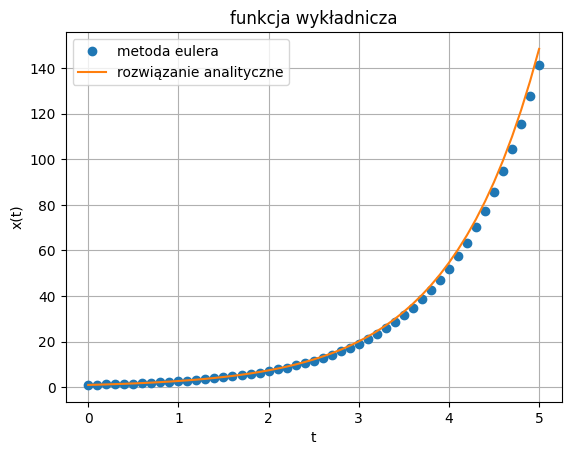

In [4]:
import matplotlib.pyplot as plt
import numpy as np

total_time = 5
step_size = 0.1

num_steps = int(total_time/step_size)

x = np.empty(num_steps + 1)
times = np.empty(num_steps + 1)

x[0] = 1
times[0] = 0

for n in range(num_steps):
    x[n+1] = x[n] + np.exp(times[n])*step_size
    times[n+1] = times[n] + step_size

plt.figure()
plt.plot(times, x, marker="o", linestyle="")
plt.plot(times, np.exp(times))
plt.title("funkcja wykładnicza")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.legend(["metoda eulera", "rozwiązanie analityczne"])
plt.grid()
plt.show()

Można pokazać, że błąd pojedyńczego kroku jest rzędu $\mathcal{O}(h^2)$, a błąd globalny $\mathcal{O}(h)$ czyli im mniejsze kroki tym większa dokładność.

## Oscylator harmoniczny
Coś oscyluje na sprężynie. 

parametr $\omega$ opisuje szybkość zmian 


zakładamy że to co oscyluje ma masę jednpstkową, czyli $m = 1$.

Ruch jest opisany wzorem:
$$
\ddot{x}(t) + \omega^2 x(t) = 0
$$

gdzie $x(t)$ jest funkcją położenia w czasie, a parametr $\omega > 0$ jest prędkością kątąwą. 

Energia układu jest opisana wzorem:

$$
E = \frac{1}{2}\dot{x}^2 + \frac{1}{2}\omega^2 x^2
$$

Wyprowadzenie tych wzorów (skąd się to wszystko wzieło) jest w tym [pliku](oscylator_harmoniczny_wyprowadzenie.ipynb).


## Rozwiązanie równań ruchu metodą eulera:

Metoda Eulera rozwiązuje układy pierwszego rzędu. W równania ruchu powyżej pojawia się pochodna rzędu drugiego. Wygodne jest wprowadzenie notacji $\dot{x} = v$. Wtedy rówanie ruchu można przekształcić w:

$$
\dot{v} = -\omega^2x
$$

Otrzymujemy wtedy układ równań:

$$
\begin{cases}
\dot{x} = v \\
\dot{v} = -\omega^2x
\end{cases}
$$

Używając reguły Eulera:

$$
\begin{cases}
x_{n+1} = x_n + h v_n\\
v_{n+1} = v_n - h \omega^2 x_n
\end{cases}
$$

### rozwiązanie analityczne
Rozwiązanie dla $x(t)$, z warunkami początkowymi $x_0$ i $v_0$.

$$
x(t) = x_0 \cos (\omega t) + \frac{v_0}{\omega} \sin (\omega t)
$$

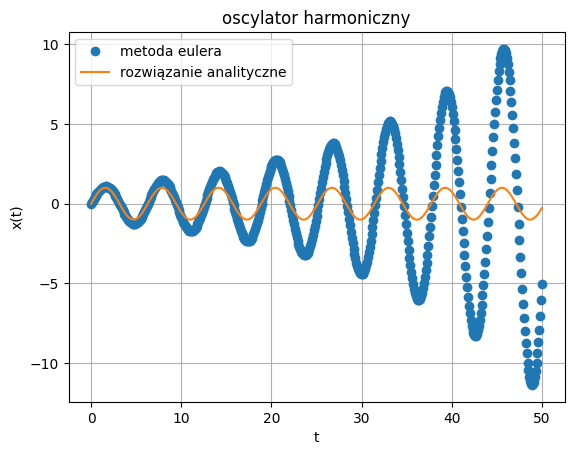

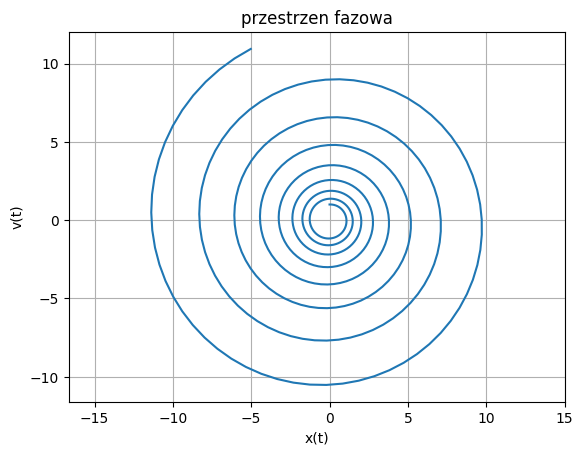

In [5]:
import matplotlib.pyplot as plt
import numpy as np


omega = 1
total_time = 50
step_size = 0.1
num_steps = int(total_time/step_size)


x = np.empty(num_steps + 1)
v = np.empty(num_steps + 1)
times = np.empty(num_steps + 1)

x[0] = 0
v[0] = 1
times[0] = 0

for n in range(num_steps):
    x[n + 1] = x[n] + step_size * v[n]
    v[n + 1] = v[n] - step_size * (omega**2) * x[n]
    times[n+1] = times[n] + step_size

def analitical_solution(t):
    return x[0] * np.cos(omega * t) + v[0]/omega * np.sin(omega * t)

plt.figure()
plt.plot(times, x,  marker="o", linestyle="")
plt.plot(times, analitical_solution(times))
plt.xlabel("t")
plt.ylabel("x(t)")
plt.legend(["metoda eulera", "rozwiązanie analityczne"])
plt.title("oscylator harmoniczny")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(x, v)
plt.xlabel("x(t)")
plt.ylabel("v(t)")
plt.title("przestrzen fazowa")
plt.axis("equal")
plt.grid(True)
plt.show()

### dlaczego eksploduje?

Energia układu powinna być stała. Łatwo to pokazać liczą pochodną po energi $E$. Warto pamiętać, że tutaj $x$ to są funckje, więc musimy użyć reguły łańcuchowej.

$$
E = \frac{1}{2}\dot{x}^2 + \frac{1}{2}\omega^2 x^2
$$

$$
\frac{dE}{dt} = \dot{x}\ddot{x} + \omega^2 x \dot{x} = \dot{x} (\ddot{x} + \omega^2 x)
$$

Z równania ruchu mamy:

$$
\ddot{x}(t) + \omega^2 x(t) = 0
$$

więc:

$$
\frac{dE}{dt} = 0
$$

Jeżeli spojrzymy na energię w chwili $t_n$ otrzymujemy:


$$
E_n = \frac{1}{2} v_n^2 + \frac{1}{2} \omega^2 x_n^2 = \frac{1}{2} (v_n^2 + \omega^2 x_n^2)
$$

Podstawiając regułę Eulera i rozwiązując mamy:

$$
E_{n+1} = (1 + h^2\omega^2) E_n 
$$

$1 + h^2\omega^2 > 1$ dla każdego $h>0$ więc energia rośnie w każdym kroku.

Jest to ogólna wada (jawnej) metody Eulera - dla niektórych układów wprowadza sztuczne wzmacnianie lub wygaszanie energii.

## Metoda symplektyczna Eulera

Intuicyjnie, metodę nazywamy symplektyczną, kiedy zachowuje pola w przestrzeni fazowej. W naszym wypadku, wystarczy delikatnie zmienić reguły aktualizacji zmiennych. Najpierw zmieniamy prędkość, a następnie aktualizujemy pozycję **używając nowej wartości prędkości**:

$$
\begin{cases}
v_{n+1} = v_n - h \omega^2 x_n\\
x_{n+1} = x_n + h v_{n+1}
\end{cases}
$$

Ważna uwaga - energia nie jest idealnie zachowana, ale odchylania są ograniczone z obu stron.

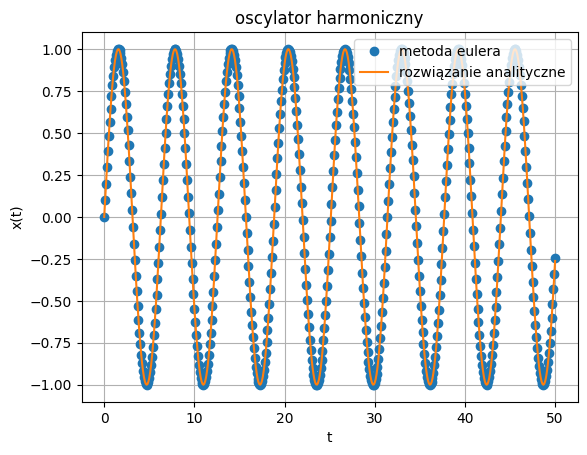

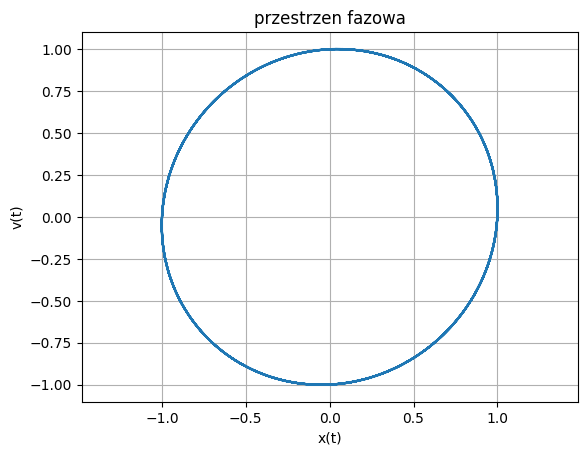

In [6]:
import matplotlib.pyplot as plt
import numpy as np


omega = 1
total_time = 50
step_size = 0.1
num_steps = int(total_time/step_size)



x = np.empty(num_steps + 1)
v = np.empty(num_steps + 1)
times = np.empty(num_steps + 1)

x[0] = 0
v[0] = 1
times[0] = 0

for n in range(num_steps):
    v[n + 1] = v[n] - step_size * (omega**2) * x[n]
    x[n + 1] = x[n] + step_size * v[n+1]
    times[n+1] = times[n] + step_size
    

def analitical_solution(t):
    return x[0] * np.cos(omega * t) + v[0]/omega * np.sin(omega * t)

plt.figure()
plt.plot(times, x,  marker="o", linestyle="")
plt.plot(times, analitical_solution(times))
plt.xlabel("t")
plt.ylabel("x(t)")
plt.legend(["metoda eulera", "rozwiązanie analityczne"], loc=1)
plt.title("oscylator harmoniczny")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(x, v)
plt.xlabel("x(t)")
plt.ylabel("v(t)")
plt.title("przestrzen fazowa")
plt.axis("equal")
plt.grid(True)
plt.show()

### Zadanie

Oscylator harmoniczny z oporem ruchu

$$
\ddot{x}(t) + 2 \omega \zeta \dot{x}(t) + \omega^2 x(t) = 0,
$$

parametr $\zeta > 0$ jest współczynnikiem tłumienia i określa wygaszanie oscylacji. 

## Bibliografia:
- Leimkuhler B, Reich S., *Simulating Hamiltonian Dynamics*, Cambridge University Press; 2005. 